In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_recall_curve, average_precision_score)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('Istanbul_Final_Analiz_Verisi.csv')

features = ['İlçe', 'Maks_Sıcaklik_C', 'Toplam_Yağış_mm', 'Maks_Rüzgar_Hızı_kmh', 'average_traffic_index', 'Ay', 'Durum']
target = 'Sağlık_Risk_Durumu'

X = df[features].copy()
y = df[target].copy()

# Kategorik verileri dönüştürme
X_encoded = pd.get_dummies(X, columns=['İlçe', 'Durum'], drop_first=True)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average='weighted')

print("="*50)
print("MAKİNE ÖĞRENMESİ MODEL PERFORMANS SONUÇLARI")
print("="*50)
print(f"Genel Doğruluk Oranı (Accuracy): %{acc * 100:.2f}")
print(f"Ağırlıklı F1-Skoru (Weighted F1): %{f1_w * 100:.2f}")
print("-" * 50)
print("DETAYLI SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, y_pred, target_names=class_names))
print("="*50)

MAKİNE ÖĞRENMESİ MODEL PERFORMANS SONUÇLARI
Genel Doğruluk Oranı (Accuracy): %96.29
Ağırlıklı F1-Skoru (Weighted F1): %96.28
--------------------------------------------------
DETAYLI SINIFLANDIRMA RAPORU:
                                   precision    recall  f1-score   support

             Düşük Risk (Güvenli)       0.98      0.98      0.98      1540
Orta Risk (Hassas Gruplar Dikkat)       0.97      0.96      0.96      1425
          Yüksek Risk (Sağlıksız)       0.84      0.94      0.89       227
      Çok Yüksek Risk (Tehlikeli)       0.67      0.40      0.50        15

                         accuracy                           0.96      3207
                        macro avg       0.86      0.82      0.83      3207
                     weighted avg       0.96      0.96      0.96      3207



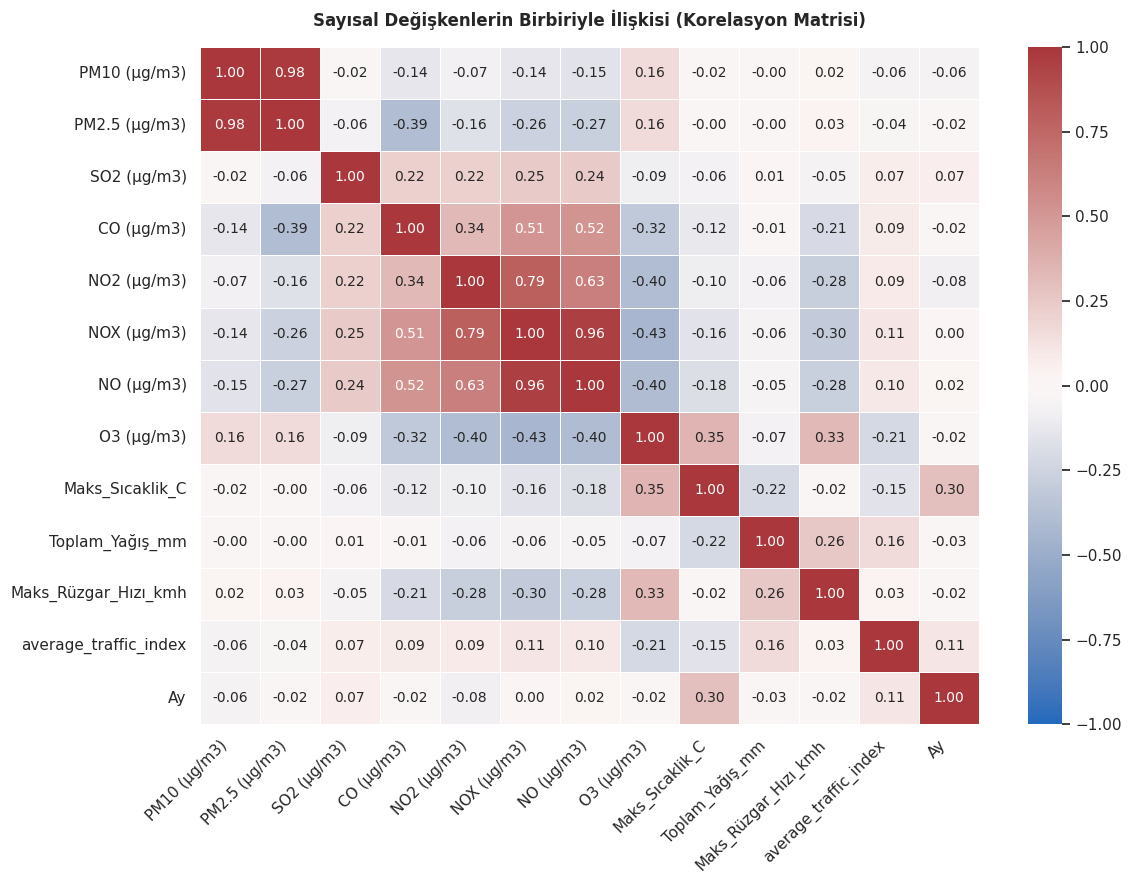

In [6]:
plt.figure(figsize=(12, 9))
korelasyon = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(korelasyon, annot=True, cmap='vlag', fmt='.2f', linewidths=0.5,
            annot_kws={"size": 10}, vmin=-1, vmax=1)
plt.title('Sayısal Değişkenlerin Birbiriyle İlişkisi (Korelasyon Matrisi)', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

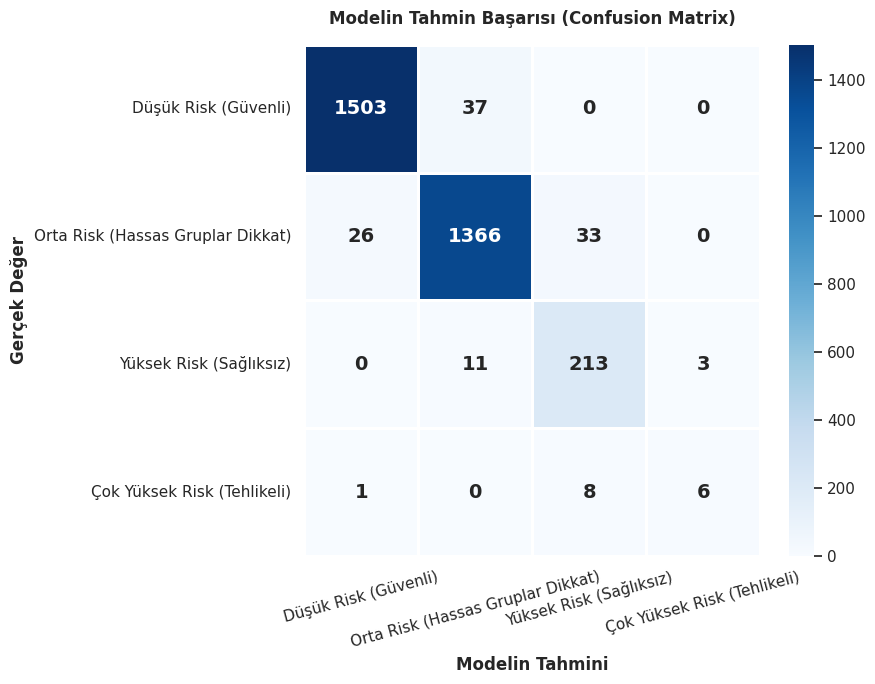

In [7]:
plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14, "weight": "bold"})
plt.xlabel('Modelin Tahmini', fontweight='bold')
plt.ylabel('Gerçek Değer', fontweight='bold')
plt.title('Modelin Tahmin Başarısı (Confusion Matrix)', fontweight='bold', pad=15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

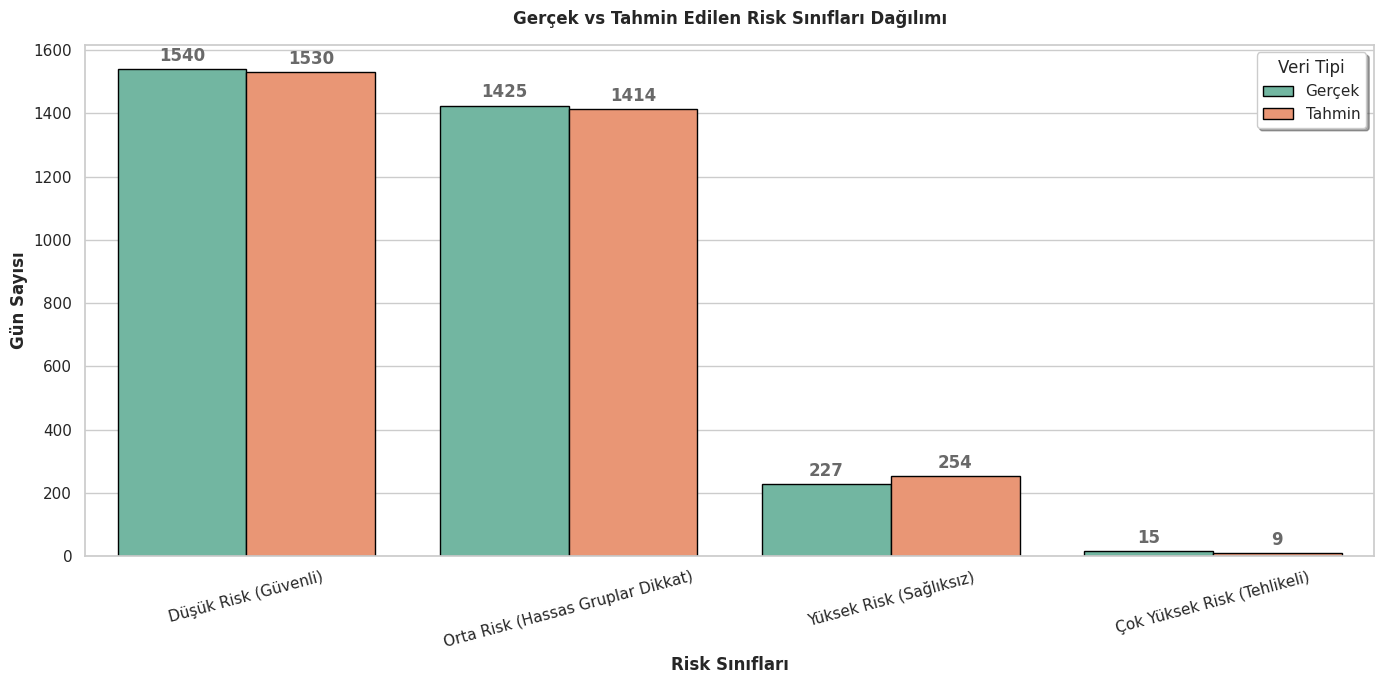

In [8]:
res_df = pd.DataFrame({
    'Risk': np.concatenate([le.inverse_transform(y_test), le.inverse_transform(y_pred)]),
    'Tip': ['Gerçek'] * len(y_test) + ['Tahmin'] * len(y_pred)
})
order = res_df[res_df['Tip'] == 'Gerçek']['Risk'].value_counts().index.tolist()

plt.figure(figsize=(14, 7))
ax = sns.countplot(data=res_df, x='Risk', hue='Tip', order=order, palette='Set2', edgecolor='black')
plt.title('Gerçek vs Tahmin Edilen Risk Sınıfları Dağılımı', fontweight='bold', pad=15)
plt.xlabel('Risk Sınıfları', fontweight='bold')
plt.ylabel('Gün Sayısı', fontweight='bold')
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold', color='dimgrey')
plt.legend(title='Veri Tipi', title_fontsize='12', shadow=True)
plt.tight_layout()
plt.show()

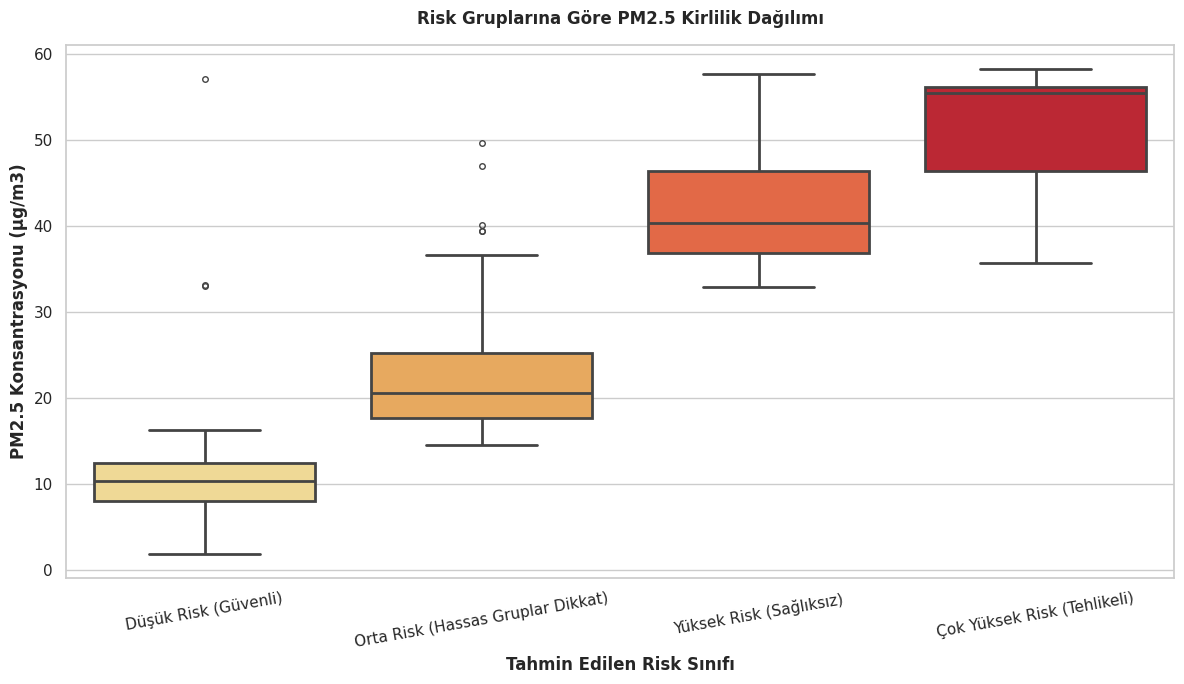

In [9]:
test_data = df.loc[X_test.index].copy()
test_data['Tahmin_Edilen_Risk'] = le.inverse_transform(y_pred)
risk_siralamasi = ['Düşük Risk (Güvenli)', 'Orta Risk (Hassas Gruplar Dikkat)', 'Yüksek Risk (Sağlıksız)', 'Çok Yüksek Risk (Tehlikeli)']

plt.figure(figsize=(12, 7))
mevcut_riskler = [r for r in risk_siralamasi if r in test_data['Tahmin_Edilen_Risk'].unique()]
sns.boxplot(data=test_data, x='Tahmin_Edilen_Risk', y='PM2.5 (µg/m3)', order=mevcut_riskler,
            palette='YlOrRd', linewidth=2, fliersize=4)
plt.title('Risk Gruplarına Göre PM2.5 Kirlilik Dağılımı', fontweight='bold', pad=15)
plt.xlabel('Tahmin Edilen Risk Sınıfı', fontweight='bold')
plt.ylabel('PM2.5 Konsantrasyonu (µg/m3)', fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

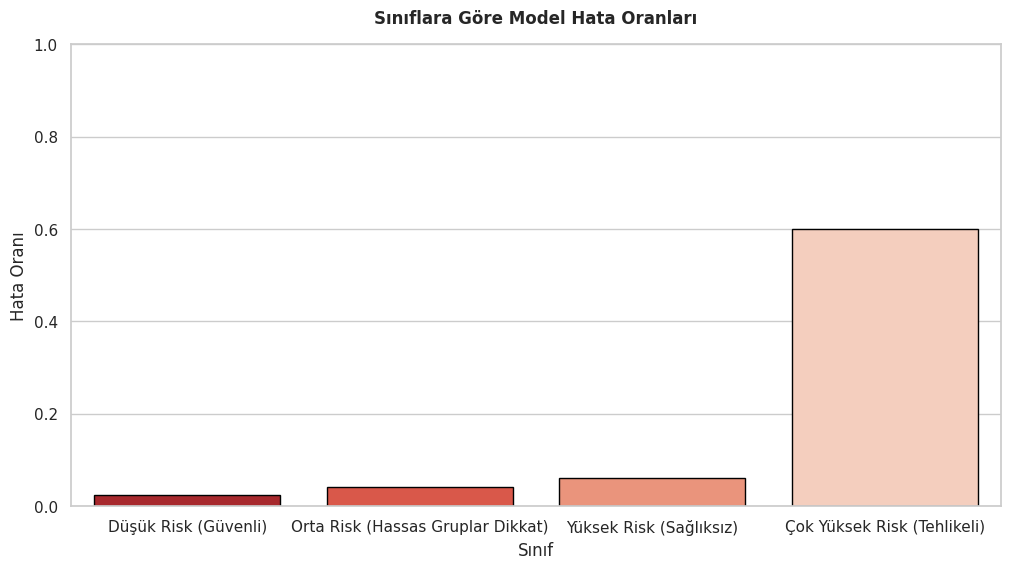

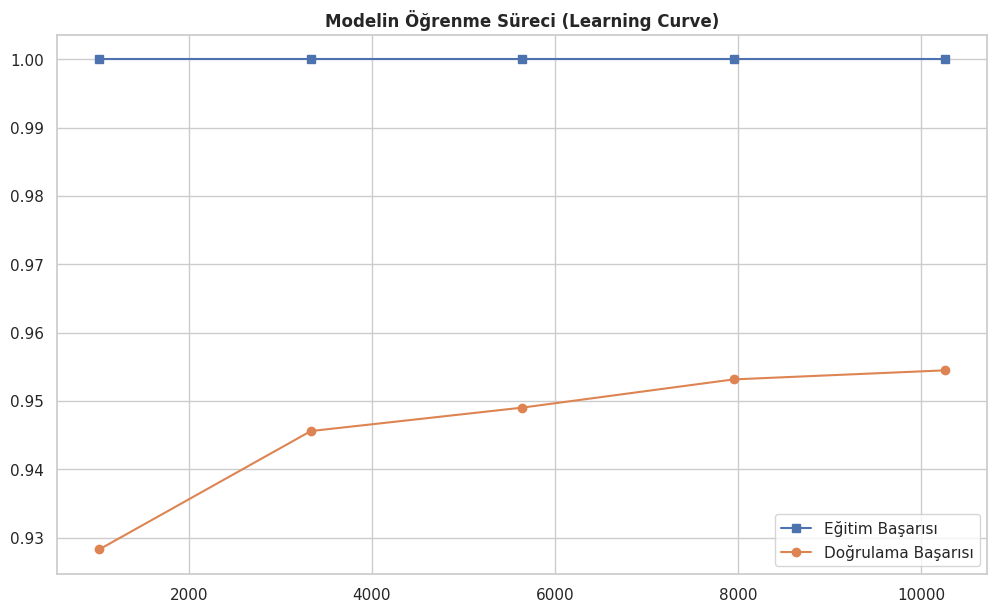

In [10]:
# Hata Oranları
plt.figure(figsize=(12, 6))
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
hata_oranlari = 1 - np.diag(cm_norm)
hata_df = pd.DataFrame({'Sınıf': class_names, 'Hata Oranı': hata_oranlari})
ax2 = sns.barplot(data=hata_df, x='Sınıf', y='Hata Oranı', palette='Reds_r', edgecolor='black')
plt.title('Sınıflara Göre Model Hata Oranları', fontweight='bold', pad=15)
plt.ylim(0, 1.0)
plt.show()

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(estimator=model, X=X_train_scaled, y=y_train, cv=5, n_jobs=-1)
plt.figure(figsize=(12, 7))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Eğitim Başarısı', marker='s')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Doğrulama Başarısı', marker='o')
plt.title('Modelin Öğrenme Süreci (Learning Curve)', fontweight='bold')
plt.legend()
plt.show()

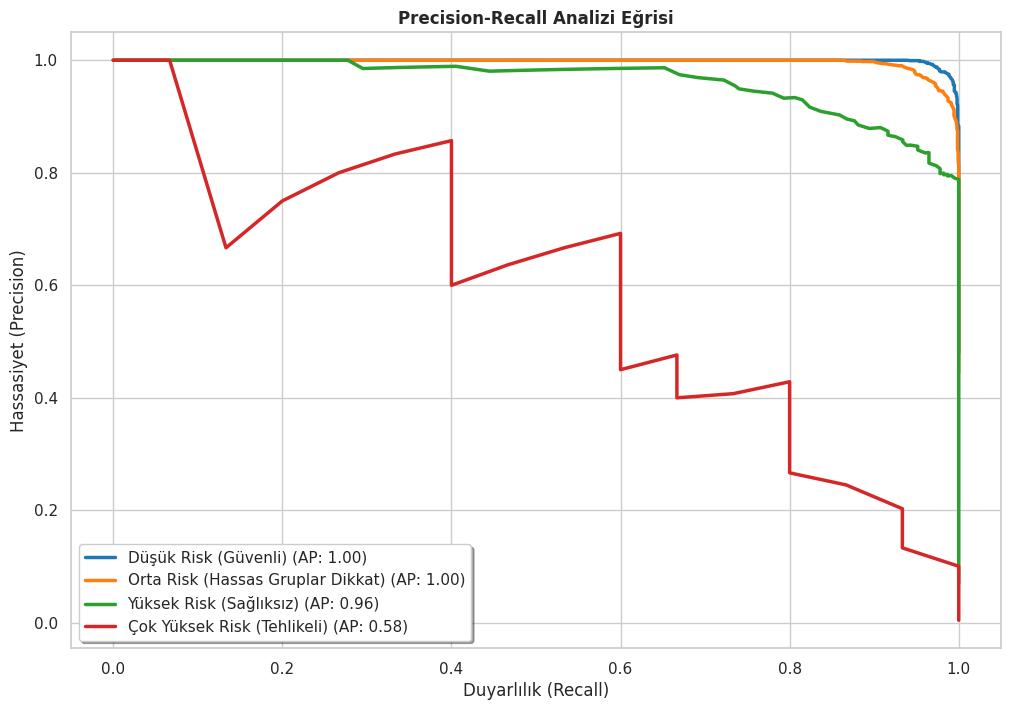

In [11]:
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
plt.figure(figsize=(12, 8))
renkler = sns.color_palette("tab10", len(class_names))

for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f'{class_names[i]} (AP: {ap:.2f})', linewidth=2.5, color=renkler[i])

plt.xlabel('Duyarlılık (Recall)')
plt.ylabel('Hassasiyet (Precision)')
plt.title('Precision-Recall Analizi Eğrisi', fontweight='bold')
plt.legend(shadow=True)
plt.show()